<a href="https://colab.research.google.com/github/LucasMaltaDS/Trabalhos-Estatistica-para-Ciencia-de-Dados/blob/main/Lucas_Malta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carregando Pacotes

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, norm
from plotly.offline import init_notebook_mode, iplot
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import numpy as np
import plotly.io as pio
pio.renderers.default = 'colab'

# Configurações para exibir gráficos no notebook
init_notebook_mode(connected=True)

# Leitura do dataset

In [ ]:
def convert_num(x):
    try:
        return float(x.replace(',', '.').strip())
    except:
        return pd.NA

enade2017 = pd.read_csv('MICRODADOS_ENADE_2017.txt',
    delimiter=';',
    encoding='latin1',
    converters={
        'NT_OBJ_CE': convert_num,
        'NT_GER': convert_num})


/tmp/ipython-input-1239046912.py:7: DtypeWarning:

Columns (29,31,32,45,46,47,54,56) have mixed types. Specify dtype option on import or set low_memory=False.



In [ ]:
enade2017

,NU_ANO,CO_IES,CO_CATEGAD,CO_ORGACAD,CO_GRUPO,CO_CURSO,CO_MODALIDADE,CO_MUNIC_CURSO,CO_UF_CURSO,CO_REGIAO_CURSO,...,QE_I72,QE_I73,QE_I74,QE_I75,QE_I76,QE_I77,QE_I78,QE_I79,QE_I80,QE_I81
0,2017,1,1,10028,5710,3,1,5103403,51,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017,1,1,10028,5710,3,1,5103403,51,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,1,1,10028,5710,3,1,5103403,51,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,1,1,10028,5710,3,1,5103403,51,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017,1,1,10028,5710,3,1,5103403,51,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537431,2017,19578,2,10022,6208,5001279,1,3513009,35,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
537432,2017,19578,2,10022,6208,5001279,1,3513009,35,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
537433,2017,19578,2,10022,6208,5001279,1,3513009,35,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
537434,2017,19578,2,10022,6208,5001279,1,3513009,35,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Seleção das variáveis desejadas
microdados_enade_filtrados = enade2017[['CO_GRUPO','CO_REGIAO_CURSO','NU_IDADE','TP_SEXO','CO_TURNO_GRADUACAO','NT_GER',
                                         'QE_I01','QE_I02','QE_I08', 'QE_I18','QE_I21','QE_I23','NT_OBJ_FG','NT_OBJ_CE']]



# Filtrando o curso de ADS

In [ ]:
microdados_ti = microdados_enade_filtrados[microdados_enade_filtrados['CO_GRUPO'] == 72].copy()

# Transformando variáveis - Colocando os labels
## Tipos dos dados transformados:
- Estado Civil: Categórico nominal
- Região: Categórico nominal
- Sexo: Categórico nominal
- Horas de Estudos: Categórico ordinal
- Cor/Raça: Categórico nominal
- Turno: Categórico nominal
- Renda Familiar: Categórico ordinal
- Intercâmbio: Categórico nominal

In [ ]:

estado_civil_map = {'A': 'Solteiro(a)', 'B': 'Casado(a)', 'C': 'Separado(a)', 'D': 'Viúvo(a)', 'E': 'Outro'}
microdados_ti['estado_civil2'] = microdados_ti['QE_I01'].map(estado_civil_map)

regiao_map = {1: 'Norte', 2: 'Nordeste', 3: 'Sudeste', 4: 'Sul', 5: 'Centro-Oeste'}
microdados_ti['regiao'] = microdados_ti['CO_REGIAO_CURSO'].map(regiao_map)

sexo_map = {'M': 'Masculino', 'F': 'Feminino'}
microdados_ti['sexo'] = microdados_ti['TP_SEXO'].map(sexo_map)

hestudos_map = {'A': 'Nenhuma, apenas assisto as aulas',
                'B': 'De uma a três',
                'C': 'De quatro a sete',
                'D': 'De oito a doze',
                'E': 'Mais de doze'}
microdados_ti['hestudos'] = microdados_ti['QE_I23'].map(hestudos_map)

microdados_ti['cor_raca'] = microdados_ti['QE_I02'].map({
    'A': 'Branca',
    'B': 'Preta',
    'C': 'Amarela',
    'D': 'Parda',
    'E': 'Indígena',
    'F': 'Não quero declarar'
})

microdados_ti['turno'] = microdados_ti['CO_TURNO_GRADUACAO'].map({
    1: 'Matutino',
    2: 'Vespertino',
    3: 'Integral',
    4: 'Noturno'
})

microdados_ti['renda_familiar'] = microdados_ti['QE_I08'].map({
'A': 'Até 1,5 salário mínimo (até R$ 1.405,50)',
'B': 'De 1,5 a 3 salários mínimos (R$ 1.405,51 a R$ 2.811,00)',
'C': 'De 3 a 4,5 salários mínimos (R$ 2.811,01 a+A1:F173 R$ 4.216,50)',
'D': 'De 4,5 a 6 salários mínimos (R$ 4.216,51 a R$ 5.622,00)',
'E': 'De 6 a 10 salários mínimos (R$ 5. 622,01 a R$ 9.370,00)',
'F': 'De 10 a 30 salários mínimos (R$ 9.370,01 a R$ 28.110,00)',
'G': 'Acima de 30 salários mínimos (mais de R$ 28.110,00)'
})

microdados_ti['intercambio'] = microdados_ti['QE_I18'].map({
    'A': 'Não participei',
    'B': 'Sim, Programa Ciência sem Fronteiras',
    'C': 'Sim, programa de intercâmbio financiado pelo Governo Federal (Marca; Brafitec; PLI; outro)',
    'D': 'Sim, programa de intercâmbio financiado pelo Governo Estadual',
    'E': 'Sim, programa de intercâmbio da minha instituição',
    'F': 'Sim, outro intercâmbio não institucional'
})

# Data quality - Remover NA's

In [ ]:
microdados_ti_sem_NA = microdados_ti.dropna()

# Estatísticas resumo da variável NT_GER

In [ ]:
microdados_ti_sem_NA['NT_GER'] = pd.to_numeric(microdados_ti_sem_NA['NT_GER'], errors='coerce')

moda_series = microdados_ti_sem_NA['NT_GER'].mode()
moda_value = moda_series.iloc[0] if not moda_series.empty else None

estatisticas = {
    'quantidade': microdados_ti_sem_NA['NT_GER'].count(),
    'media': microdados_ti_sem_NA['NT_GER'].mean(),
    'mediana': microdados_ti_sem_NA['NT_GER'].median(),
    'moda': moda_value,
    'cv': microdados_ti_sem_NA['NT_GER'].std() / microdados_ti_sem_NA['NT_GER'].mean() * 100,
    'assimetria': skew(microdados_ti_sem_NA['NT_GER']),
    'curtose': kurtosis(microdados_ti_sem_NA['NT_GER'])
}
print(estatisticas)

{'quantidade': np.int64(9636), 'media': np.float64(40.236249481112495), 'mediana': 39.6, 'moda': np.float64(39.4), 'cv': np.float64(32.02865461732685), 'assimetria': np.float64(0.19575463614700594), 'curtose': np.float64(-0.10745982240520924)}


/tmp/ipython-input-3292573277.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



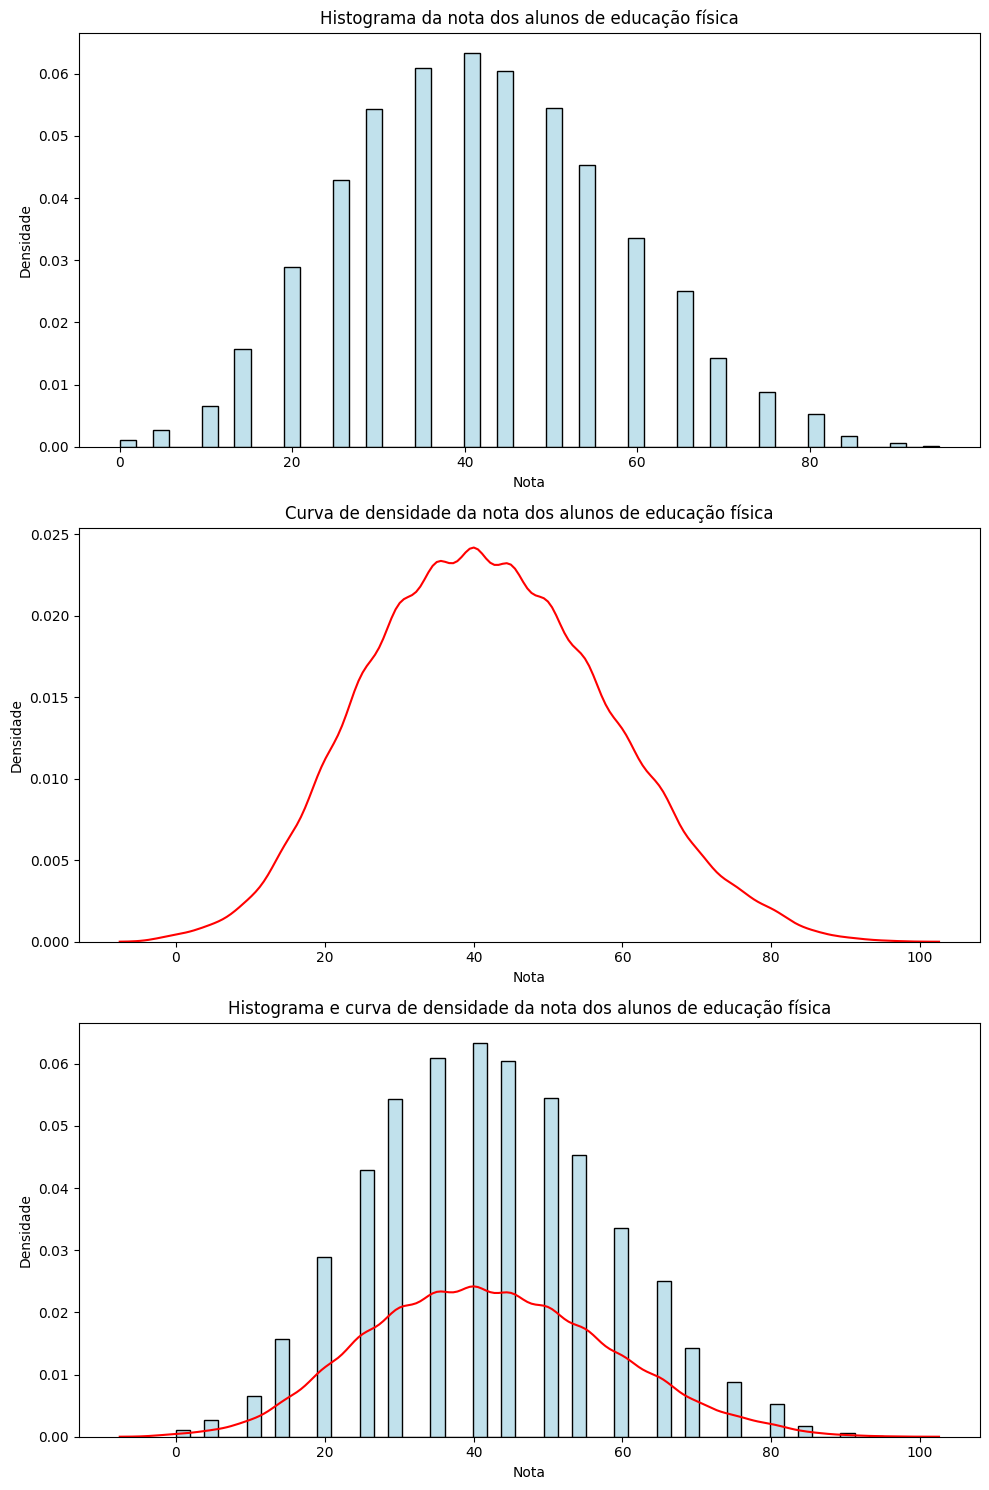

In [ ]:
# Gráficos da análise descritiva para nota dos alunos de E.F.
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Histograma
sns.histplot(microdados_ti_sem_NA['NT_OBJ_CE'], bins=50, stat='density', color='lightblue', ax=axs[0], edgecolor='black')
axs[0].set_title('Histograma da nota dos alunos de educação física')
axs[0].set_xlabel('Nota')
axs[0].set_ylabel('Densidade')

# Curva de densidade
sns.kdeplot(microdados_ti_sem_NA['NT_OBJ_CE'], color='red', ax=axs[1])
axs[1].set_title('Curva de densidade da nota dos alunos de educação física')
axs[1].set_xlabel('Nota')
axs[1].set_ylabel('Densidade')

# Histograma e curva de densidade juntos
sns.histplot(microdados_ti_sem_NA['NT_OBJ_CE'], bins=50, stat='density', color='lightblue', ax=axs[2], edgecolor='black')
sns.kdeplot(microdados_ti_sem_NA['NT_OBJ_CE'], color='red', ax=axs[2])
axs[2].set_title('Histograma e curva de densidade da nota dos alunos de educação física')
axs[2].set_xlabel('Nota')
axs[2].set_ylabel('Densidade')

plt.tight_layout()
plt.show()


In [ ]:
# Comparando médias por turno e renda familiar
grouped_turno_renda = microdados_ti_sem_NA.groupby(['turno', 'renda_familiar']).agg(
    quantidade=('NT_GER', 'count'),
    media=('NT_GER', 'mean'),
    mediana=('NT_GER', 'median'),
    cv=('NT_GER', lambda x: x.std() / x.mean() * 100),
    amplitude_interquartil=('NT_GER', lambda x: x.quantile(0.75) - x.quantile(0.25))
).reset_index().sort_values(by='mediana', ascending=False)
print(grouped_turno_renda)

         turno                                     renda_familiar  quantidade  \
7     Matutino  Acima de 30 salários mínimos (mais de R$ 28.11...           4   
10    Matutino  De 10 a 30 salários mínimos (R$ 9.370,01 a R$ ...          73   
13    Matutino  De 6 a 10 salários mínimos (R$ 5. 622,01 a R$ ...         158   
12    Matutino  De 4,5 a 6 salários mínimos (R$ 4.216,51 a R$ ...         196   
3     Integral  De 10 a 30 salários mínimos (R$ 9.370,01 a R$ ...         119   
17     Noturno  De 10 a 30 salários mínimos (R$ 9.370,01 a R$ ...         397   
26  Vespertino  De 4,5 a 6 salários mínimos (R$ 4.216,51 a R$ ...          90   
27  Vespertino  De 6 a 10 salários mínimos (R$ 5. 622,01 a R$ ...          95   
5     Integral  De 4,5 a 6 salários mínimos (R$ 4.216,51 a R$ ...         109   
25  Vespertino  De 3 a 4,5 salários mínimos (R$ 2.811,01 a+A1:...         178   
23  Vespertino  De 1,5 a 3 salários mínimos (R$ 1.405,51 a R$ ...         179   
24  Vespertino  De 10 a 30 s

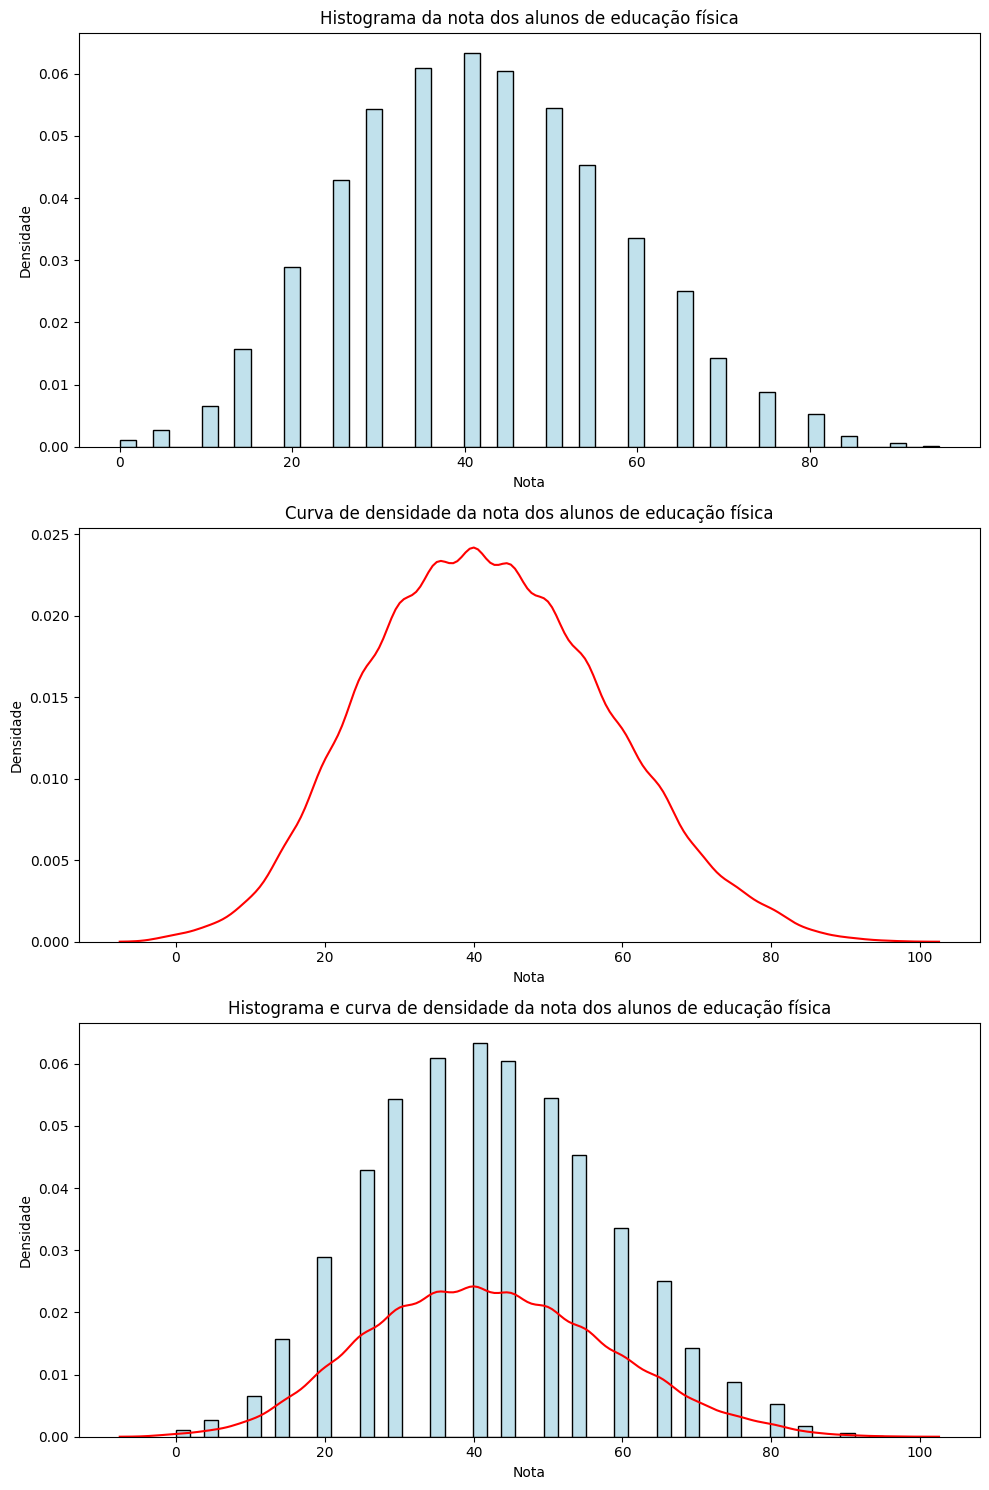

In [ ]:
# Gráficos da análise descritiva para nota dos alunos de E.F.
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Histograma
sns.histplot(microdados_ti_sem_NA['NT_OBJ_CE'], bins=50, stat='density', color='lightblue', ax=axs[0], edgecolor='black')
axs[0].set_title('Histograma da nota dos alunos de educação física')
axs[0].set_xlabel('Nota')
axs[0].set_ylabel('Densidade')

# Curva de densidade
sns.kdeplot(microdados_ti_sem_NA['NT_OBJ_CE'], color='red', ax=axs[1])
axs[1].set_title('Curva de densidade da nota dos alunos de educação física')
axs[1].set_xlabel('Nota')
axs[1].set_ylabel('Densidade')

# Histograma e curva de densidade juntos
sns.histplot(microdados_ti_sem_NA['NT_OBJ_CE'], bins=50, stat='density', color='lightblue', ax=axs[2], edgecolor='black')
sns.kdeplot(microdados_ti_sem_NA['NT_OBJ_CE'], color='red', ax=axs[2])
axs[2].set_title('Histograma e curva de densidade da nota dos alunos de educação física')
axs[2].set_xlabel('Nota')
axs[2].set_ylabel('Densidade')

plt.tight_layout()
plt.show()

# Tabulação cruzada de estado civil vs sexo

In [ ]:
tab_civil_sexo = pd.crosstab(microdados_ti_sem_NA['renda_familiar'], microdados_ti_sem_NA['turno'])
print(tab_civil_sexo)

# Proporção da tabulação cruzada
prop_tab_civil_sexo = tab_civil_sexo.div(tab_civil_sexo.sum().sum())
print(prop_tab_civil_sexo)

turno                                               Integral  Matutino  \
renda_familiar                                                           
Acima de 30 salários mínimos (mais de R$ 28.110...         4         4   
Até 1,5 salário mínimo (até R$ 1.405,50)                 119       197   
De 1,5 a 3 salários mínimos (R$ 1.405,51 a R$ 2...       217       373   
De 10 a 30 salários mínimos (R$ 9.370,01 a R$ 2...       119        73   
De 3 a 4,5 salários mínimos (R$ 2.811,01 a+A1:F...       205       347   
De 4,5 a 6 salários mínimos (R$ 4.216,51 a R$ 5...       109       196   
De 6 a 10 salários mínimos (R$ 5. 622,01 a R$ 9...       170       158   

turno                                               Noturno  Vespertino  
renda_familiar                                                           
Acima de 30 salários mínimos (mais de R$ 28.110...       16           1  
Até 1,5 salário mínimo (até R$ 1.405,50)                901          84  
De 1,5 a 3 salários mínimos (R$ 1.405

# Estatísticas por estado civil com assimetria e curtose


In [ ]:
microdados_ti_sem_NA['NT_GER'] = pd.to_numeric(microdados_ti_sem_NA['NT_GER'], errors='coerce')

grouped_casados = microdados_ti_sem_NA.groupby('estado_civil2').agg(
    quantidade=('NT_GER', 'count'),
    media=('NT_GER', 'mean'),
    mediana=('NT_GER', 'median'),
    cv=('NT_GER', lambda x: x.std() / x.mean() * 100),
    amplitude_interquartil=('NT_GER', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    assimetria=('NT_GER', skew),
    curtose=('NT_GER', kurtosis)
).reset_index().sort_values(by='cv', ascending=False)
print(grouped_casados)



  estado_civil2  quantidade      media  mediana         cv  \
2   Separado(a)         183  39.667213     38.7  33.421247   
0     Casado(a)        1850  38.808595     37.9  33.339006   
1         Outro         303  39.694059     39.3  33.139982   
3   Solteiro(a)        7289  40.646934     40.1  31.569824   
4      Viúvo(a)          11  32.609091     33.6  22.246682   

   amplitude_interquartil  assimetria   curtose  
2                   15.95    0.311546  0.479959  
0                   17.60    0.324484 -0.009493  
1                   17.15    0.371457  0.197163  
3                   17.90    0.153336 -0.143612  
4                    7.65   -0.494407 -0.765152  


/tmp/ipython-input-2482672660.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Gráficos histograma e boxplot pela variável estado Renda e Turno

/tmp/ipython-input-1367617616.py:14: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



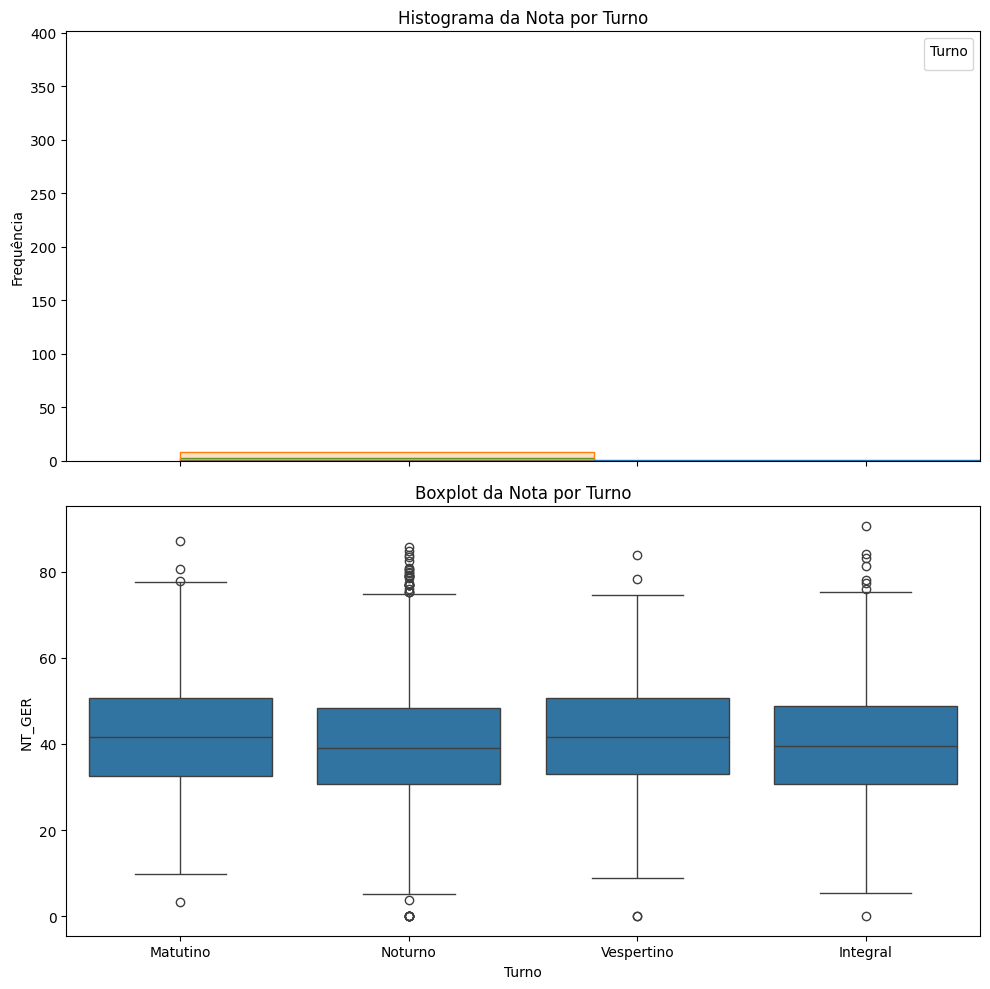

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Histogram
sns.histplot(
    data=microdados_ti_sem_NA, x='NT_GER', hue='turno',
    bins=50, element='step', kde=False, stat='count', ax=axes[0]
)
axes[0].set_title('Histograma da Nota por Turno')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frequência')
axes[0].legend(title='Turno')

# Boxplot
sns.boxplot(
    data=microdados_ti_sem_NA, x='turno', y='NT_GER', ax=axes[1]
)
axes[1].set_title('Boxplot da Nota por Turno')
axes[1].set_xlabel('Turno')
axes[1].set_ylabel('NT_GER')

plt.tight_layout()
plt.show()


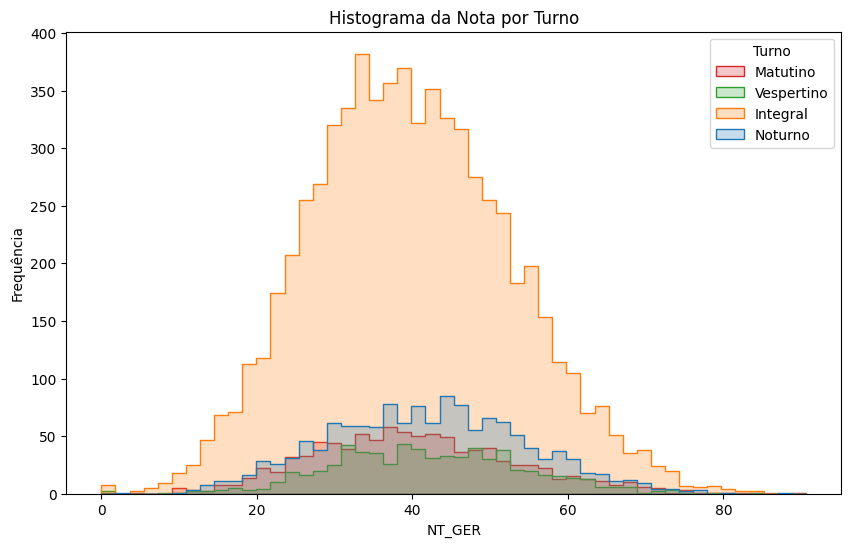

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=microdados_ti_sem_NA, x='NT_GER', hue='turno',
             bins=50, element='step', kde=False, stat='count')
plt.title('Histograma da Nota por Turno')
plt.xlabel('NT_GER')
plt.ylabel('Frequência')
plt.legend(['Matutino', 'Vespertino', 'Integral', 'Noturno'], title='Turno')
plt.show()


# Comparando as médias por sexo e região

In [ ]:

grouped_turno_regiao = microdados_ti_sem_NA.groupby(['turno', 'regiao']).agg(
    quantidade=('NT_GER', 'count'),
    media=('NT_GER', 'mean'),
    mediana=('NT_GER', 'median'),
    cv=('NT_GER', lambda x: x.std() / x.mean() * 100),
    amplitude_interquartil=('NT_GER', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    assimetria=('NT_GER', skew),
    curtose=('NT_GER', kurtosis)
).reset_index().sort_values(by='media', ascending=False)
print(grouped_turno_regiao)

         turno        regiao  quantidade      media  mediana         cv  \
17  Vespertino           Sul          13  48.246154    42.20  34.029675   
1     Integral      Nordeste          71  47.449296    44.30  24.473916   
14  Vespertino      Nordeste          55  44.060000    48.00  32.529508   
15  Vespertino         Norte          70  43.044286    45.40  25.282976   
7     Matutino       Sudeste         933  42.284244    42.60  30.374379   
8     Matutino           Sul         209  42.118660    42.00  29.331844   
0     Integral  Centro-Oeste          24  41.975000    42.20  40.645918   
6     Matutino      Nordeste         129  41.763566    41.80  30.643096   
16  Vespertino       Sudeste         526  41.604943    41.25  29.164106   
4     Integral           Sul          11  40.890909    38.10  25.426342   
12     Noturno       Sudeste        3447  40.079780    39.50  31.738959   
13     Noturno           Sul        1851  39.918639    39.40  33.393028   
3     Integral       Sude

# Tabulação cruzada região x turno


In [ ]:
tab_regiao_turno = pd.crosstab(microdados_ti_sem_NA['regiao'], microdados_ti_sem_NA['turno'])
print(tab_regiao_turno)

# Proporção da tabulação cruzada
prop_tab_regiao_turno = tab_regiao_turno.div(tab_regiao_turno.sum().sum())
print(prop_tab_regiao_turno)

turno         Integral  Matutino  Noturno  Vespertino
regiao                                               
Centro-Oeste        24        77      614           0
Nordeste            71       129      598          55
Norte               22         0      171          70
Sudeste            815       933     3447         526
Sul                 11       209     1851          13
turno         Integral  Matutino   Noturno  Vespertino
regiao                                                
Centro-Oeste  0.002491  0.007991  0.063719    0.000000
Nordeste      0.007368  0.013387  0.062059    0.005708
Norte         0.002283  0.000000  0.017746    0.007264
Sudeste       0.084579  0.096824  0.357721    0.054587
Sul           0.001142  0.021689  0.192092    0.001349


# Gráficos histograma e boxplot para região e turno

In [ ]:
pio.renderers.default = 'colab'


In [ ]:
fig_hist2 = px.histogram(microdados_ti_sem_NA, x='NT_GER', color='regiao', title='Histograma da Nota por região e turno',
                         nbins=50, barmode='overlay', facet_col='turno')
fig_hist2.show()

fig_box2 = px.box(microdados_ti_sem_NA, x='regiao', y='NT_GER', color='regiao', title='Boxplot da Nota por região e turno',
                  facet_col='turno')
fig_box2.update_xaxes(tickangle=90)
fig_box2.show()

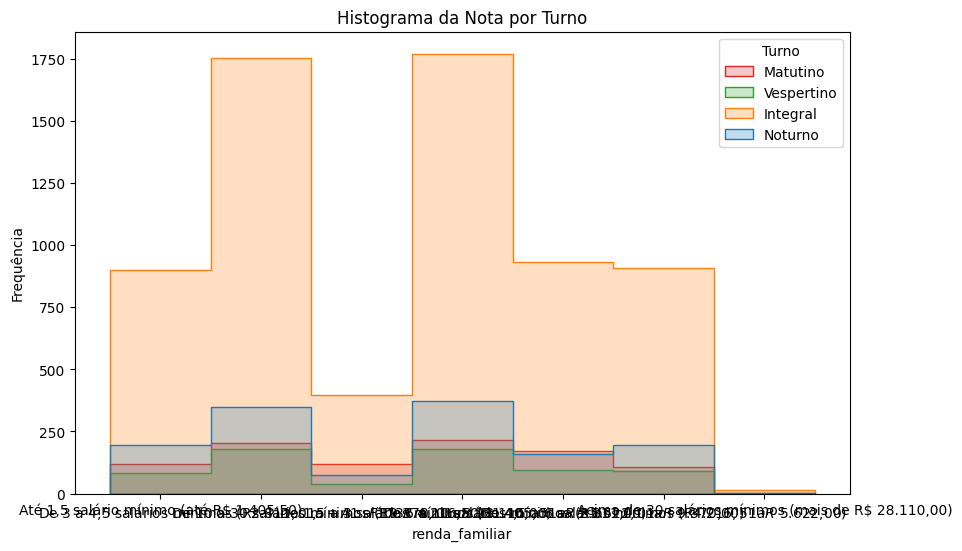

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=microdados_ti_sem_NA, x='renda_familiar', hue='turno',
             bins=50, element='step', kde=False, stat='count')
plt.title('Histograma da Nota por Turno')
plt.xlabel('renda_familiar')
plt.ylabel('Frequência')
plt.legend(['Matutino', 'Vespertino', 'Integral', 'Noturno'], title='Turno')
plt.show()

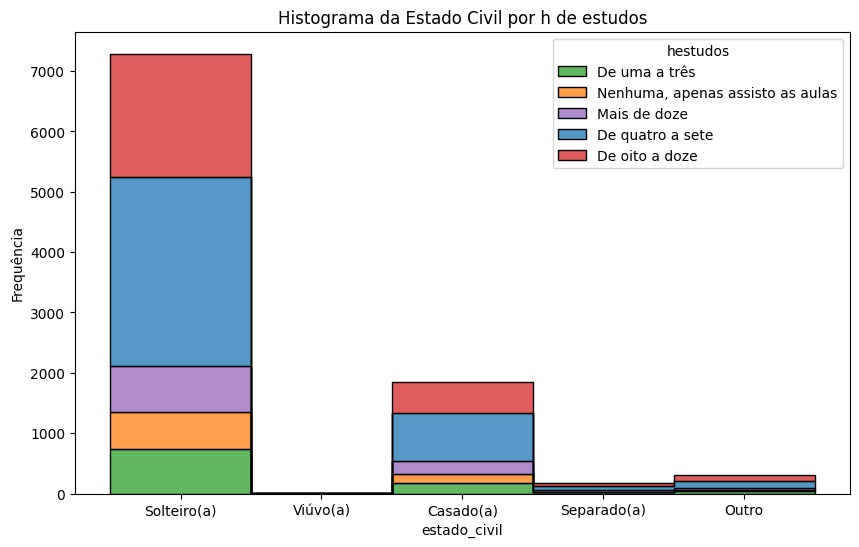

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=microdados_ti_sem_NA, x='estado_civil2', hue='hestudos',
             bins=50, element='step', kde=False, stat='count', multiple='stack', palette={'De uma a três': '#1f77b4', 'Nenhuma, apenas assisto as aulas': '#ff7f0e', 'Mais de doze': '#2ca02c', 'De quatro a sete': '#d62728', 'De oito a doze': '#9467bd'})
plt.title('Histograma da Estado Civil por h de estudos')
plt.xlabel('estado_civil')
plt.ylabel('Frequência')
plt.legend(['De uma a três', 'Nenhuma, apenas assisto as aulas', 'Mais de doze', 'De quatro a sete', 'De oito a doze'], title='hestudos')
plt.show()

In [ ]:
# Converter horas de estudo para escala numérica
horas_estudo_map = {'A': 0, 'B': 2, 'C': 5.5, 'D': 10, 'E': 16}
microdados_ti_sem_NA['horas_estudo_num'] = microdados_ti_sem_NA['QE_I23'].map(horas_estudo_map)

# Aplicar TLC para analisar a média de horas de estudo
amostras = []
for _ in range(1000):  # 1000 amostras
    amostra = microdados_ti_sem_NA['horas_estudo_num'].dropna().sample(30, replace=True)
    amostras.append(amostra.mean())

# Analisar distribuição das médias amostrais

/tmp/ipython-input-2196012170.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/tmp/ipython-input-75129676.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



=== ANÁLISE DA DISTRIBUIÇÃO ORIGINAL ===
Tamanho da população: 9636
Média populacional: 4.96 horas
Desvio padrão populacional: 4.07 horas
Assimetria (skewness): 1.06
Curtose: -0.01


Simulando TLC com amostras de tamanho n = 5...
  n = 5: Média das médias = 4.98, Std das médias = 1.76
Simulando TLC com amostras de tamanho n = 10...
  n = 10: Média das médias = 4.90, Std das médias = 1.28
Simulando TLC com amostras de tamanho n = 30...
  n = 30: Média das médias = 4.91, Std das médias = 0.73
Simulando TLC com amostras de tamanho n = 50...
  n = 50: Média das médias = 4.97, Std das médias = 0.57
Simulando TLC com amostras de tamanho n = 100...
  n = 100: Média das médias = 4.96, Std das médias = 0.41


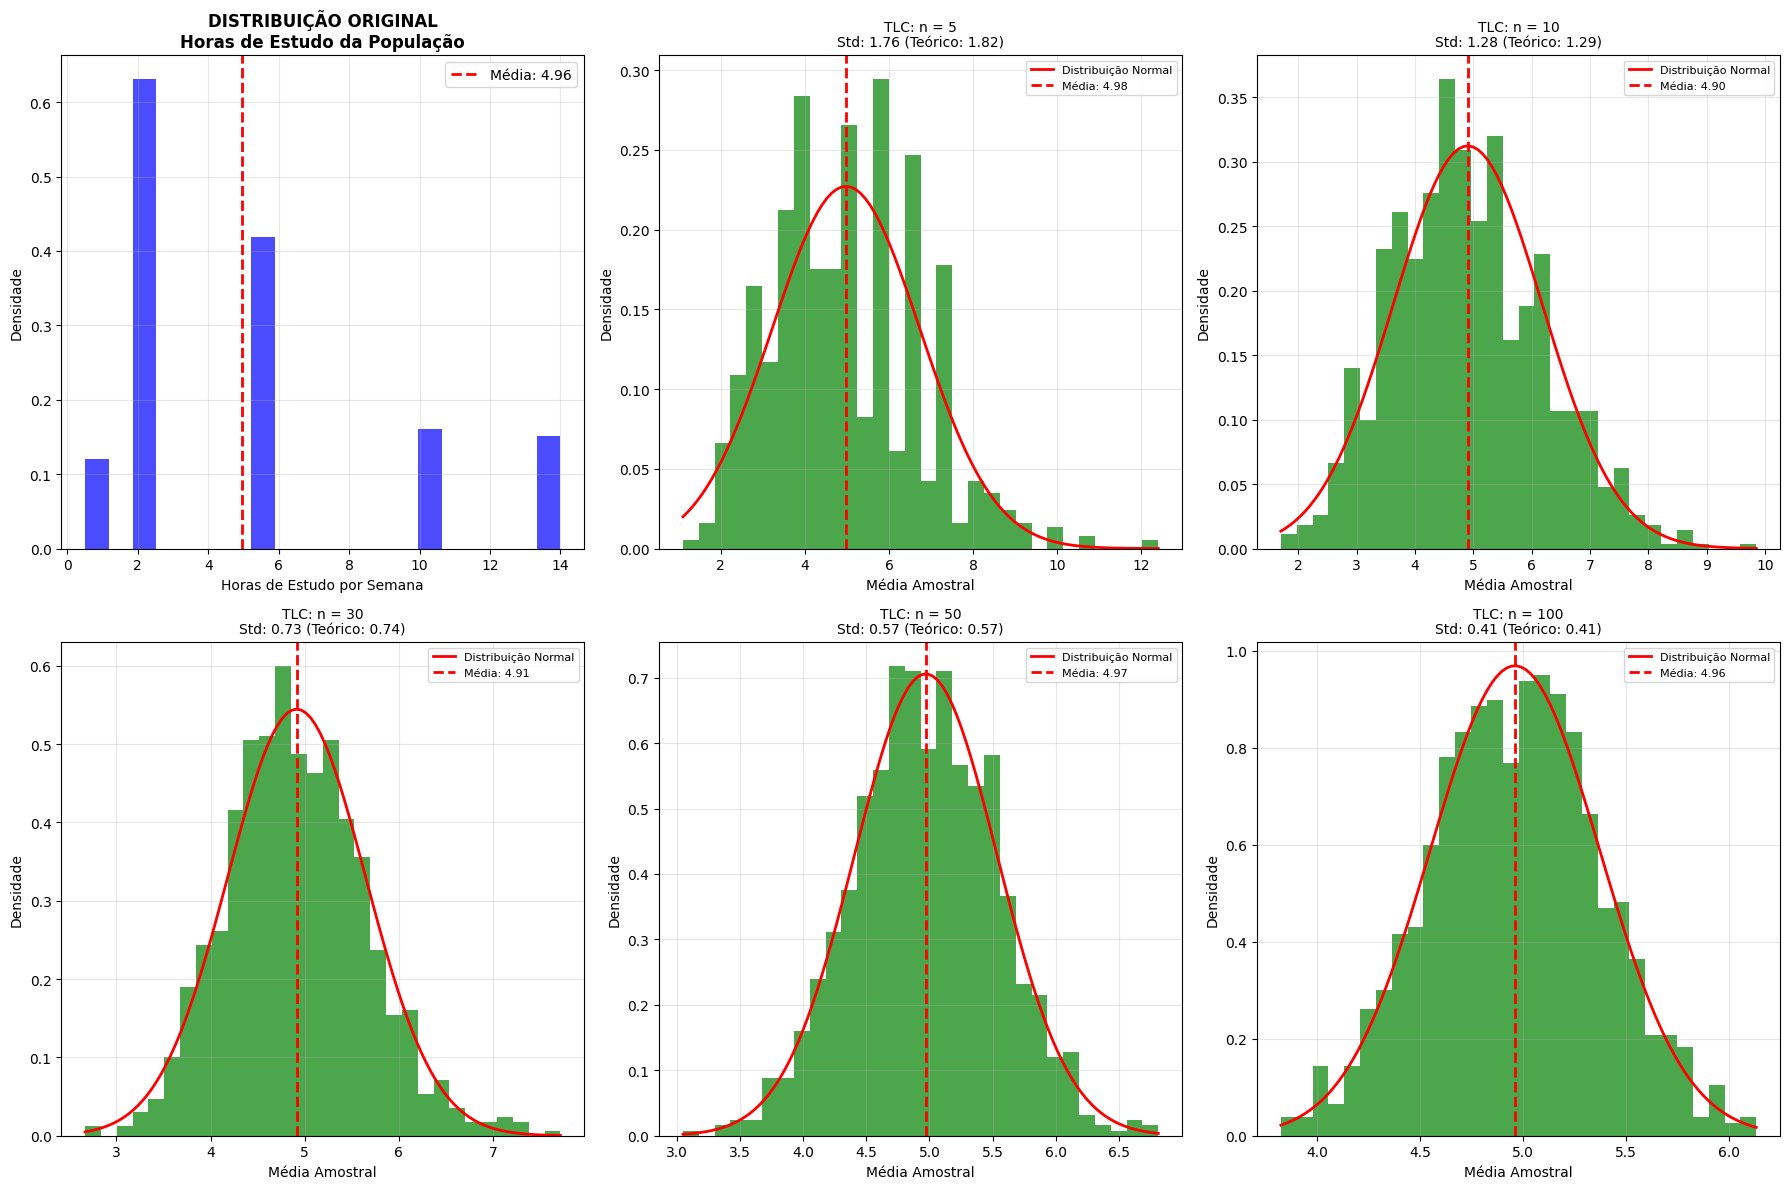


=== ANÁLISE COMPARATIVA DO TLC ===
Comparação da distribuição original vs distribuição das médias (n=50):

DISTRIBUIÇÃO ORIGINAL:
  Assimetria (skewness): 1.060
  Curtose: -0.008

DISTRIBUIÇÃO DAS MÉDIAS (n=50):
  Assimetria (skewness): 0.028 (próximo de 0 = simétrico)
  Curtose: -0.014 (próximo de 0 = normal)

MELHORIA NA NORMALIDADE:
  Redução da assimetria: 1.032
  Aproximação da curtose normal: -0.006


In [ ]:
horas_estudo_map_convertido = {'A': 0.5, 'B': 2, 'C': 5.5, 'D': 10, 'E': 14}
microdados_ti_sem_NA['horas_estudo_num'] = microdados_ti_sem_NA['QE_I23'].map(horas_estudo_map_convertido)
dados_originais = microdados_ti_sem_NA['horas_estudo_num'].dropna().values

print("=== ANÁLISE DA DISTRIBUIÇÃO ORIGINAL ===")
print(f"Tamanho da população: {len(dados_originais)}")
print(f"Média populacional: {np.mean(dados_originais):.2f} horas")
print(f"Desvio padrão populacional: {np.std(dados_originais):.2f} horas")
print(f"Assimetria (skewness): {skew(dados_originais):.2f}")
print(f"Curtose: {kurtosis(dados_originais):.2f}")
print("\n")

# ============================================================================
# SEGUNDO: CRIAR FIGURA PARA COMPARAÇÃO VISUAL
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ============================================================================
# GRÁFICO 1: DISTRIBUIÇÃO ORIGINAL DOS DADOS (ANTES DO TLC)
# ============================================================================

axes[0,0].hist(dados_originais, bins=20, alpha=0.7, color='blue', density=True)
axes[0,0].axvline(np.mean(dados_originais), color='red', linestyle='--',
                  linewidth=2, label=f'Média: {np.mean(dados_originais):.2f}')
axes[0,0].set_title('DISTRIBUIÇÃO ORIGINAL\nHoras de Estudo da População',
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Horas de Estudo por Semana')
axes[0,0].set_ylabel('Densidade')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# ============================================================================
# TERCEIRO: SIMULAR O TLC COM DIFERENTES TAMANHOS DE AMOSTRA
# ============================================================================

# Definir diferentes tamanhos de amostra para demonstrar o TLC
tamanhos_amostra = [5, 10, 30, 50, 100]
n_simulacoes = 1000  # Número de amostras para cada tamanho

# Dicionário para armazenar resultados
resultados_tlc = {}

for idx, n in enumerate(tamanhos_amostra):
    print(f"Simulando TLC com amostras de tamanho n = {n}...")

    # Lista para armazenar as médias das amostras
    medias_amostrais = []

    # ========================================================================
    # SIMULAÇÃO: Gerar múltiplas amostras e calcular suas médias
    # ========================================================================
    for i in range(n_simulacoes):
        # Pegar uma amostra aleatória de tamanho n (com reposição)
        amostra = np.random.choice(dados_originais, size=n, replace=True)
        # Calcular a média da amostra e armazenar
        medias_amostrais.append(np.mean(amostra))

    medias_amostrais = np.array(medias_amostrais)
    resultados_tlc[n] = medias_amostrais

    # ========================================================================
    # GRÁFICO: Plotar distribuição das médias amostrais
    # ========================================================================

    # Determinar em qual posição do grid plotar
    row = (idx + 1) // 3
    col = (idx + 1) % 3

    # Histograma das médias amostrais
    axes[row, col].hist(medias_amostrais, bins=30, alpha=0.7,
                        color='green', density=True)

    # ========================================================================
    # CALCULAR ESTATÍSTICAS IMPORTANTES PARA O TLC
    # ========================================================================

    media_das_medias = np.mean(medias_amostrais)
    std_das_medias = np.std(medias_amostrais)
    erro_padrao_teorico = np.std(dados_originais) / np.sqrt(n)

    # ========================================================================
    # ADICIONAR CURVA NORMAL TEÓRICA (o que o TLC prevê)
    # ========================================================================
    x = np.linspace(min(medias_amostrais), max(medias_amostrais), 100)
    curva_normal = norm.pdf(x, media_das_medias, std_das_medias)
    axes[row, col].plot(x, curva_normal, 'r-', linewidth=2,
                        label='Distribuição Normal')

    # Linha vertical na média das médias
    axes[row, col].axvline(media_das_medias, color='red', linestyle='--',
                          linewidth=2,
                          label=f'Média: {media_das_medias:.2f}')

    # ========================================================================
    # CONFIGURAR O GRÁFICO
    # ========================================================================
    axes[row, col].set_title(f'TLC: n = {n}\n'
                            f'Std: {std_das_medias:.2f} (Teórico: {erro_padrao_teorico:.2f})',
                            fontsize=10)
    axes[row, col].set_xlabel('Média Amostral')
    axes[row, col].set_ylabel('Densidade')
    axes[row, col].legend(fontsize=8)
    axes[row, col].grid(True, alpha=0.3)

    print(f"  n = {n}: Média das médias = {media_das_medias:.2f}, "
          f"Std das médias = {std_das_medias:.2f}")

# ============================================================================
# QUARTO: COMPARAÇÃO FINAL - ANTES vs DEPOIS DO TLC
# ============================================================================

plt.tight_layout()
plt.show()

# ============================================================================
# QUINTO: ANÁLISE NUMÉRICA DETALHADA
# ============================================================================

print("\n=== ANÁLISE COMPARATIVA DO TLC ===")
print("Comparação da distribuição original vs distribuição das médias (n=50):")

# Estatísticas da distribuição original
skew_original = skew(dados_originais)
kurt_original = kurtosis(dados_originais)

# Estatísticas da distribuição das médias (n=50)
medias_n50 = resultados_tlc[50]
skew_n50 = skew(medias_n50)
kurt_n50 = kurtosis(medias_n50)

print(f"\nDISTRIBUIÇÃO ORIGINAL:")
print(f"  Assimetria (skewness): {skew_original:.3f}")
print(f"  Curtose: {kurt_original:.3f}")

print(f"\nDISTRIBUIÇÃO DAS MÉDIAS (n=50):")
print(f"  Assimetria (skewness): {skew_n50:.3f} (próximo de 0 = simétrico)")
print(f"  Curtose: {kurt_n50:.3f} (próximo de 0 = normal)")

print(f"\nMELHORIA NA NORMALIDADE:")
print(f"  Redução da assimetria: {abs(skew_original) - abs(skew_n50):.3f}")
print(f"  Aproximação da curtose normal: {abs(kurt_original) - abs(kurt_n50):.3f}")

In [ ]:
"""
Análise Binomial: Probabilidade de ter feito intercâmbio entre alunos com nota > 80
"""
# 1. Preparar as variáveis
# Variável de intercâmbio (binária)
intercambio_bin_map = {
    'A': 0,  # Não
    'B': 1,  # Sim
    'C': 1,  # Sim
    'D': 1,  # Sim
    'E': 1,  # Sim
    'F': 1   # Sim
}
microdados_ti_sem_NA['intercambio_bin'] = microdados_ti_sem_NA['QE_I18'].map(intercambio_bin_map)

# 2. Criar grupo de alunos com nota > 80
microdados_ti_sem_NA['nota_alta'] = (microdados_ti_sem_NA['NT_GER'] > 80).astype(int)

# Filtrar apenas alunos com nota alta
alunos_nota_alta = microdados_ti_sem_NA[microdados_ti_sem_NA['nota_alta'] == 1]

# 3. Parâmetros da distribuição binomial
n_alta = len(alunos_nota_alta)  # número de trials (alunos com nota alta)
x_alta = alunos_nota_alta['intercambio_bin'].sum()  # número de sucessos (com intercâmbio)
p_alta = x_alta / n_alta  # probabilidade de sucesso

print("=== ANÁLISE BINOMIAL - INTERCÂMBIO ENTRE ALUNOS COM NOTA > 80 ===")
print(f"Total de alunos com nota > 80: {n_alta}")
print(f"Alunos com nota > 80 que fizeram intercâmbio: {x_alta}")
print(f"Probabilidade binomial: p = {p_alta:.4f} ({p_alta*100:.2f}%)")

# 4. Comparar com a população geral
n_geral = len(microdados_ti_sem_NA.dropna(subset=['intercambio_bin']))
x_geral = microdados_ti_sem_NA['intercambio_bin'].sum()
p_geral = x_geral / n_geral

print(f"\nCOMPARAÇÃO COM POPULAÇÃO GERAL:")
print(f"Total de alunos: {n_geral}")
print(f"Alunos que fizeram intercâmbio: {x_geral}")
print(f"Probabilidade geral: p = {p_geral:.4f} ({p_geral*100:.2f}%)")

# 5. Razão de chances (Odds Ratio)
odds_alta = p_alta / (1 - p_alta) if p_alta < 1 else float('inf')
odds_geral = p_geral / (1 - p_geral) if p_geral < 1 else float('inf')
odds_ratio = odds_alta / odds_geral if odds_geral > 0 else float('inf')

print(f"\nRAZÃO DE CHANCES (Odds Ratio):")
print(f"Odds (nota > 80): {odds_alta:.4f}")
print(f"Odds (geral): {odds_geral:.4f}")
print(f"Odds Ratio: {odds_ratio:.4f}")

if odds_ratio > 1:
    print(f"Alunos com nota > 80 têm {odds_ratio:.2f}x MAIS chance de ter feito intercâmbio")
else:
    print(f"Alunos com nota > 80 têm {1/odds_ratio:.2f}x MENOS chance de ter feito intercâmbio")

=== ANÁLISE BINOMIAL - INTERCÂMBIO ENTRE ALUNOS COM NOTA > 80 ===
Total de alunos com nota > 80: 15
Alunos com nota > 80 que fizeram intercâmbio: 6
Probabilidade binomial: p = 0.4000 (40.00%)

COMPARAÇÃO COM POPULAÇÃO GERAL:
Total de alunos: 9636
Alunos que fizeram intercâmbio: 2094
Probabilidade geral: p = 0.2173 (21.73%)

RAZÃO DE CHANCES (Odds Ratio):
Odds (nota > 80): 0.6667
Odds (geral): 0.2776
Odds Ratio: 2.4011
Alunos com nota > 80 têm 2.40x MAIS chance de ter feito intercâmbio


/tmp/ipython-input-3099635685.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-3099635685.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/tmp/ipython-input-372414624.py:37: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-372414624.py:41: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



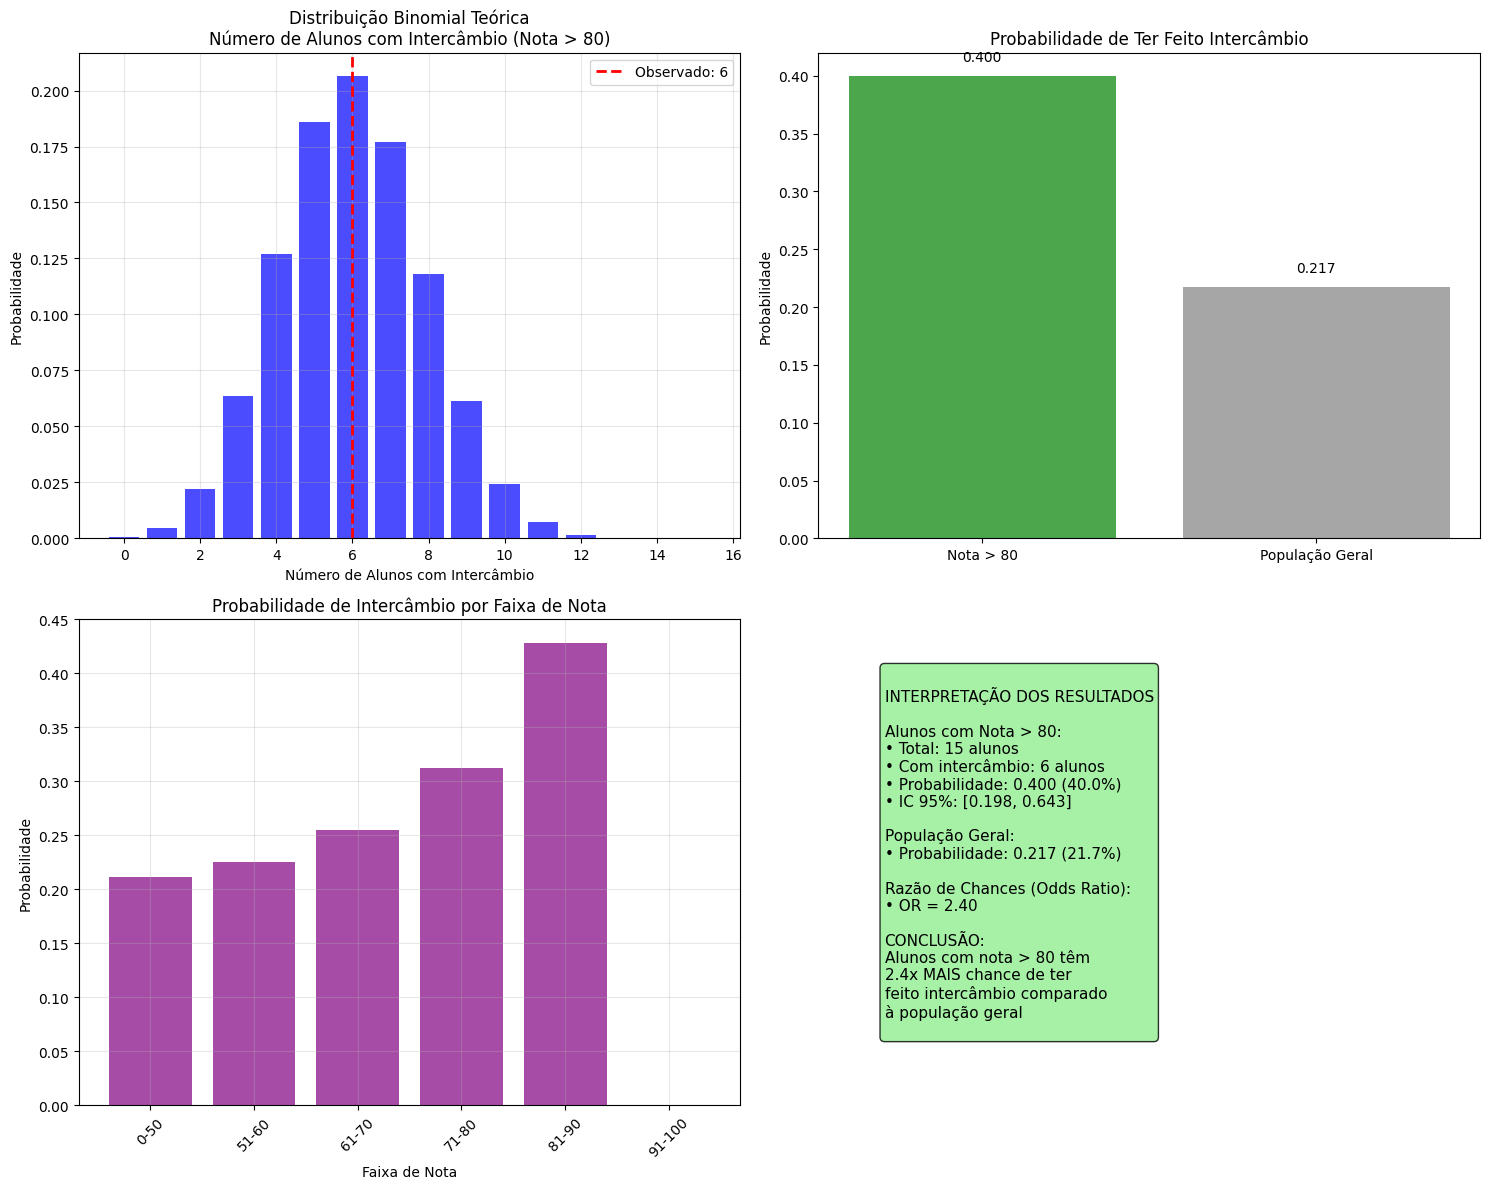

In [ ]:
"""
Visualização da análise binomial: intercâmbio entre alunos com nota alta
"""
from scipy.stats import binom

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Distribuição binomial teórica
k_values = range(0, min(n_alta + 1, 21))  # Número possível de alunos com intercâmbio
prob_teorica = [binom.pmf(k, n_alta, p_alta) for k in k_values]

axes[0,0].bar(k_values, prob_teorica, alpha=0.7, color='blue')
axes[0,0].axvline(x_alta, color='red', linestyle='--', linewidth=2,
                  label=f'Observado: {x_alta}')
axes[0,0].set_title('Distribuição Binomial Teórica\nNúmero de Alunos com Intercâmbio (Nota > 80)')
axes[0,0].set_xlabel('Número de Alunos com Intercâmbio')
axes[0,0].set_ylabel('Probabilidade')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Gráfico 2: Comparação de probabilidades
categorias = ['Nota > 80', 'População Geral']
probabilidades = [p_alta, p_geral]
cores = ['green' if p_alta > p_geral else 'red', 'gray']

bars = axes[0,1].bar(categorias, probabilidades, color=cores, alpha=0.7)
axes[0,1].set_title('Probabilidade de Ter Feito Intercâmbio')
axes[0,1].set_ylabel('Probabilidade')

# Adicionar valores nas barras
for bar, prob in zip(bars, probabilidades):
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                  f'{prob:.3f}', ha='center', va='bottom')

# Gráfico 3: Probabilidade por faixa de nota
microdados_ti_sem_NA['faixa_nota'] = pd.cut(microdados_ti_sem_NA['NT_GER'],
                                    bins=[0, 50, 60, 70, 80, 90, 100],
                                    labels=['0-50', '51-60', '61-70', '71-80', '81-90', '91-100'])

intercambio_por_faixa = microdados_ti_sem_NA.groupby('faixa_nota')['intercambio_bin'].mean()

axes[1,0].bar(intercambio_por_faixa.index, intercambio_por_faixa.values,
              alpha=0.7, color='purple')
axes[1,0].set_title('Probabilidade de Intercâmbio por Faixa de Nota')
axes[1,0].set_xlabel('Faixa de Nota')
axes[1,0].set_ylabel('Probabilidade')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# Gráfico 4: Resumo e interpretação
axes[1,1].axis('off')

# Calcular intervalo de confiança para p_alta
from statsmodels.stats.proportion import proportion_confint
ci_inf, ci_sup = proportion_confint(x_alta, n_alta, alpha=0.05, method='wilson')

texto_interpretacao = f"""
INTERPRETAÇÃO DOS RESULTADOS

Alunos com Nota > 80:
• Total: {n_alta} alunos
• Com intercâmbio: {x_alta} alunos
• Probabilidade: {p_alta:.3f} ({p_alta*100:.1f}%)
• IC 95%: [{ci_inf:.3f}, {ci_sup:.3f}]

População Geral:
• Probabilidade: {p_geral:.3f} ({p_geral*100:.1f}%)

Razão de Chances (Odds Ratio):
• OR = {odds_ratio:.2f}

CONCLUSÃO:
Alunos com nota > 80 têm
{odds_ratio:.1f}x MAIS chance de ter
feito intercâmbio comparado
à população geral
"""

if odds_ratio > 1:
    cor_caixa = 'lightgreen'
else:
    cor_caixa = 'lightcoral'

axes[1,1].text(0.1, 0.9, texto_interpretacao, transform=axes[1,1].transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor=cor_caixa, alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
def analise_poisson_intercambio_regiao(microdados_ti):
    """
    Análise de Poisson: Frequência de intercâmbio por região geográfica,
    modelando intercâmbios POR ALUNO.
    """
    import pandas as pd

    # Criar cópia segura
    dados = microdados_ti.copy()

    # 1. Preparar variáveis
    intercambio_bin_map = {
        'A': 0, 'B': 1, 'C': 1, 'D': 1, 'E': 1, 'F': 1
    }
    dados.loc[:, 'intercambio_bin'] = dados['QE_I18'].map(intercambio_bin_map)

    # Mapear regiões
    regiao_map = {
        1: 'Norte',
        2: 'Nordeste',
        3: 'Sudeste',
        4: 'Sul',
        5: 'Centro-Oeste'
    }
    dados.loc[:, 'regiao'] = dados['CO_REGIAO_CURSO'].map(regiao_map)

    # Filtrar dados completos
    dados_completos = dados.dropna(subset=['intercambio_bin', 'regiao'])

    print("=== ANÁLISE DE POISSON - INTERCÂMBIO POR REGIÃO ===")

    # 2. Estatísticas por região
    stats_regiao = dados_completos.groupby('regiao').agg({
        'intercambio_bin': ['count', 'sum', 'mean']
    }).round(4)

    stats_regiao.columns = ['total_alunos', 'total_intercambio', 'taxa_intercambio']

    # 3. Modelar intercâmbios por aluno (λ proporcional)
    # λ = taxa média * escala (por 100 alunos, p.ex.)
    escala = 100  # número base de alunos
    stats_regiao['lambda_poisson'] = stats_regiao['taxa_intercambio'] * escala

    print("Estatísticas por região (λ padronizado por 100 alunos):")
    print(stats_regiao)

    return stats_regiao, dados_completos


# Executar análise
stats_regiao, dados_completos = analise_poisson_intercambio_regiao(microdados_ti_sem_NA)


=== ANÁLISE DE POISSON - INTERCÂMBIO POR REGIÃO ===
Estatísticas por região (λ padronizado por 100 alunos):
              total_alunos  total_intercambio  taxa_intercambio  \
regiao                                                            
Centro-Oeste           715                129            0.1804   
Nordeste               853                163            0.1911   
Norte                  263                 49            0.1863   
Sudeste               5721               1281            0.2239   
Sul                   2084                472            0.2265   

              lambda_poisson  
regiao                        
Centro-Oeste           18.04  
Nordeste               19.11  
Norte                  18.63  
Sudeste                22.39  
Sul                    22.65  


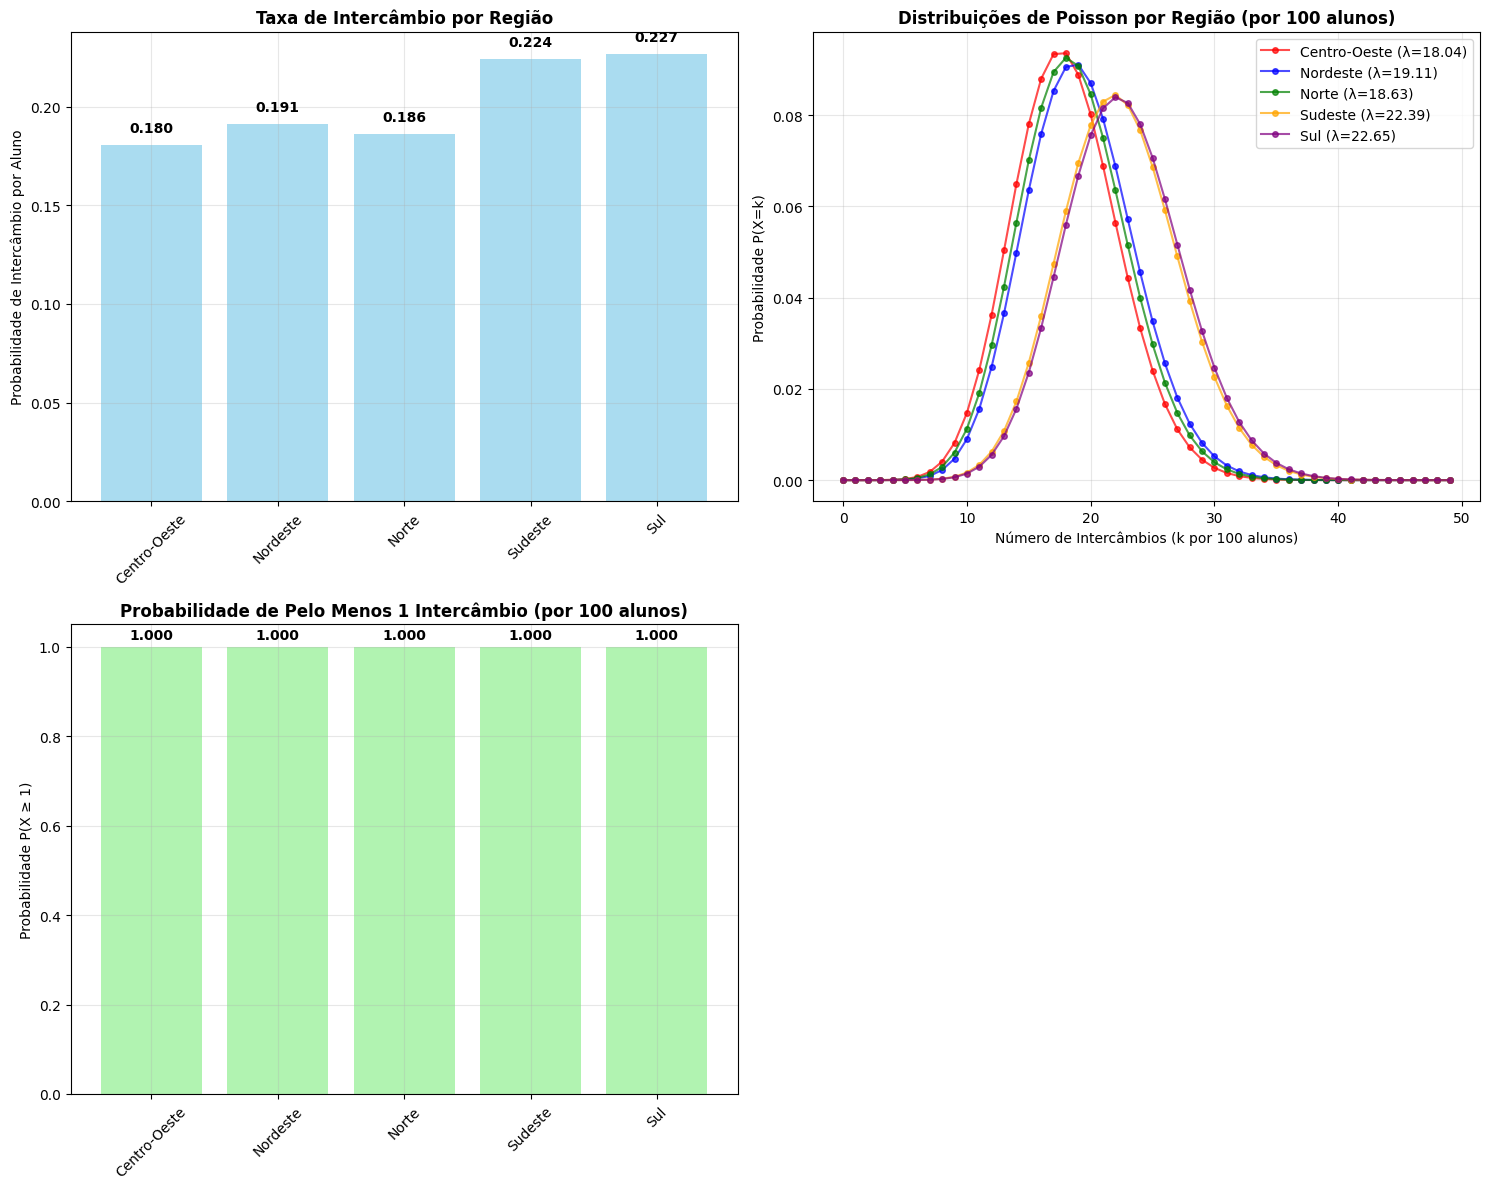


RESUMO ESTATÍSTICO - POISSON POR REGIÃO (por 100 alunos)

CENTRO-OESTE:
  λ = 18.04
  P(X=0) = 0.000
  P(X=1) = 0.000
  P(X≥2) = 1.000
  E[X] = 18.04, σ = 4.25

NORDESTE:
  λ = 19.11
  P(X=0) = 0.000
  P(X=1) = 0.000
  P(X≥2) = 1.000
  E[X] = 19.11, σ = 4.37

NORTE:
  λ = 18.63
  P(X=0) = 0.000
  P(X=1) = 0.000
  P(X≥2) = 1.000
  E[X] = 18.63, σ = 4.32

SUDESTE:
  λ = 22.39
  P(X=0) = 0.000
  P(X=1) = 0.000
  P(X≥2) = 1.000
  E[X] = 22.39, σ = 4.73

SUL:
  λ = 22.65
  P(X=0) = 0.000
  P(X=1) = 0.000
  P(X≥2) = 1.000
  E[X] = 22.65, σ = 4.76


In [ ]:
"""
Visualização da análise de Poisson por região - COM GRÁFICO ADICIONAL
"""
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

# Criar figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Taxa de intercâmbio por região
regions = stats_regiao.index
taxas = stats_regiao['taxa_intercambio']

bars = axes[0,0].bar(regions, taxas, alpha=0.7, color='skyblue')
axes[0,0].set_title('Taxa de Intercâmbio por Região', fontweight='bold')
axes[0,0].set_ylabel('Probabilidade de Intercâmbio por Aluno')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

for bar, taxa in zip(bars, taxas):
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                  f'{taxa:.3f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Distribuições de Poisson (λ ajustado)
x = np.arange(0, 50)  # Agora faz sentido trabalhar com números pequenos
colors = ['red', 'blue', 'green', 'orange', 'purple']

for idx, (regiao, row) in enumerate(stats_regiao.iterrows()):
    lambda_reg = row['lambda_poisson']
    prob_poisson = poisson.pmf(x, lambda_reg)
    axes[0,1].plot(x, prob_poisson, 'o-', color=colors[idx],
                  label=f'{regiao} (λ={lambda_reg:.2f})', alpha=0.7, markersize=4)

axes[0,1].set_title('Distribuições de Poisson por Região (por 100 alunos)', fontweight='bold')
axes[0,1].set_xlabel('Número de Intercâmbios (k por 100 alunos)')
axes[0,1].set_ylabel('Probabilidade P(X=k)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Gráfico 3: Probabilidade de pelo menos 1 intercâmbio (por 100 alunos)
prob_pelo_menos_1 = []

for regiao, row in stats_regiao.iterrows():
    lambda_reg = row['lambda_poisson']
    prob_0 = poisson.pmf(0, lambda_reg)
    prob_pelo_menos_1.append(1 - prob_0)

bars = axes[1,0].bar(regions, prob_pelo_menos_1, alpha=0.7, color='lightgreen')
axes[1,0].set_title('Probabilidade de Pelo Menos 1 Intercâmbio (por 100 alunos)', fontweight='bold')
axes[1,0].set_ylabel('Probabilidade P(X ≥ 1)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

for bar, prob in zip(bars, prob_pelo_menos_1):
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                  f'{prob:.3f}', ha='center', va='bottom', fontweight='bold')

# Remove o subplot vazio
fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()

# Resumo estatístico
print("\n" + "="*50)
print("RESUMO ESTATÍSTICO - POISSON POR REGIÃO (por 100 alunos)")
print("="*50)

for regiao, row in stats_regiao.iterrows():
    lambda_reg = row['lambda_poisson']
    print(f"\n{regiao.upper()}:")
    print(f"  λ = {lambda_reg:.2f}")
    print(f"  P(X=0) = {poisson.pmf(0, lambda_reg):.3f}")
    print(f"  P(X=1) = {poisson.pmf(1, lambda_reg):.3f}")
    print(f"  P(X≥2) = {1 - poisson.cdf(1, lambda_reg):.3f}")
    print(f"  E[X] = {lambda_reg:.2f}, σ = {np.sqrt(lambda_reg):.2f}")
